# Who Hunts Who?
## Comparing Three Knowledge Graph Construction Methods for Predator–Prey Relations

### Goal
Build a predator–prey knowledge graph from ~20 Wikipedia animal pages and compare three extraction approaches:

1. **Method A – Co-occurrence**
2. **Method B – Dependency Patterns**
3. **Method C – OpenIE-style Relation Extraction**

All methods are evaluated against the same gold standard using Precision, Recall and F1.


---
## Section 0 – Setup & Imports

In [138]:
# 0.1  Install dependencies (run once; comment out after first execution)
# After running this cell for the first time, restart the kernel and comment these lines out.
#!pip install -q wikipedia-api spacy networkx pandas matplotlib seaborn
#!python -m spacy download en_core_web_md -q

In [139]:
# 0.2 Imports
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
import spacy
import wikipediaapi


pd.set_option("display.max_colwidth", 120)
%matplotlib inline
print("Imports loaded.")

Imports loaded.


---
## Section 1 – Dataset

A controlled corpus of ~20 Wikipedia animal pages forming a simple terrestrial food web. The corpus contains predators, intermediate species and common prey to allow multi-hop chains.


In [140]:
# 1.1  Animal lists and Wikipedia page title mapping

PREDATORS = ["Hawk", "Eagle", "Owl", "Fox", "Wolf", "Snake"]

MID_LEVEL = ["Frog", "Lizard", "Spider", "Bird", "Shrew", "Bat"]

PREY = ["Mouse", "Rabbit", "Squirrel", "Grasshopper", "Cricket", "Caterpillar", "Fly", "Beetle"]

ALL_ANIMALS = PREDATORS + MID_LEVEL + PREY

# Map animal label → exact Wikipedia page title.
# Most match directly; override here where the general page title differs.
WIKI_PAGE_MAP = {
    "Hawk":        "Hawk",
    "Eagle":       "Eagle",
    "Owl":         "Owl",
    "Fox":         "Fox",
    "Wolf":        "Wolf",
    "Snake":       "Snake",
    "Frog":        "Frog",
    "Lizard":      "Lizard",
    "Spider":      "Spider",
    "Bird":        "Bird",
    "Shrew":       "Shrew",
    "Bat":         "Bat",
    "Mouse":       "Mouse",
    "Rabbit":      "Rabbit",
    "Squirrel":    "Squirrel",
    "Grasshopper": "Grasshopper",
    "Cricket":     "Cricket (insect)",   # disambiguation: cricket sport vs insect
    "Caterpillar": "Caterpillar",
    "Fly":         "Fly",
    "Beetle":      "Beetle",
}

# Trophic colour map — used later for graph visualisations
TROPHIC_COLOR = {
    animal: color
    for animals, color in [
        (PREDATORS, "#e05c5c"),   # red   – top predators
        (MID_LEVEL, "#f0a500"),   # amber – mid-level
        (PREY,      "#4da06d"),   # green – lower trophic
    ]
    for animal in animals
}

print(f"Animal corpus: {len(ALL_ANIMALS)} animals total")
print(f"  Predators : {PREDATORS}")
print(f"  Mid-level : {MID_LEVEL}")
print(f"  Prey      : {PREY}")

Animal corpus: 20 animals total
  Predators : ['Hawk', 'Eagle', 'Owl', 'Fox', 'Wolf', 'Snake']
  Mid-level : ['Frog', 'Lizard', 'Spider', 'Bird', 'Shrew', 'Bat']
  Prey      : ['Mouse', 'Rabbit', 'Squirrel', 'Grasshopper', 'Cricket', 'Caterpillar', 'Fly', 'Beetle']


### 1.2 Fetching Wikipedia Pages

For each animal we retrieve:
- **Full plain text** of the page (for Methods A and B)
- **Internal wikilinks** (list of pages linked from this page, for Method C)

Pages are fetched once and cached locally (as a dict or JSON file) to avoid repeated API calls during development.

In [141]:
# 1.2 Fetch and cache Wikipedia pages
CACHE_PATH = Path("corpus_cache.json")

def build_bootstrap_corpus(page_map: dict) -> dict:
    """Small offline fallback corpus."""
    bootstrap_text = {
        "Hawk": "Hawk hunts mice and rabbits.",
        "Eagle": "Eagle hunts rabbits and squirrels.",
        "Owl": "Owl preys on mice.",
        "Fox": "Fox feeds on rabbits and mice.",
        "Wolf": "Wolf hunts rabbits.",
        "Snake": "Snake eats frogs and mice.",
        "Frog": "Frog eats insects.",
        "Lizard": "Lizard eats insects.",
        "Spider": "Spider eats flies.",
        "Bird": "Bird feeds on insects.",
        "Shrew": "Shrew eats beetles.",
        "Bat": "Bat feeds on beetles and flies.",
    }
    return {
        animal: {
            "title": animal,
            "url": f"bootstrap://{animal.lower()}",
            "text": bootstrap_text.get(animal, f"{animal} appears in the ecosystem."),
            "links": [],
        }
        for animal in page_map.keys()
    }

def fetch_corpus(page_map: dict, force_refresh: bool = False, allow_bootstrap_fallback: bool = True) -> dict:
    """Fetch Wikipedia pages, prefer cache when present."""
    if CACHE_PATH.exists() and not force_refresh:
        print(f"Loading corpus from cache: {CACHE_PATH}")
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)

    print("Fetching pages from Wikipedia API...")
    wiki = wikipediaapi.Wikipedia(
        language="en",
        user_agent="NLP-MAI-SS2026/1.0 (university project; contact: student@example.com)",
    )

    corpus = {}
    try:
        for animal, title in page_map.items():
            page = wiki.page(title)
            if not page.exists():
                print(f"Warning: page not found for '{animal}' (title '{title}').")
                continue
            corpus[animal] = {
                "title": page.title,
                "url": page.fullurl,
                "text": page.text,
                "links": list(page.links.keys()),
            }
            print(f"Loaded {animal:15s} ({len(page.text):,} chars, {len(page.links)} links)")

        with open(CACHE_PATH, "w", encoding="utf-8") as f:
            json.dump(corpus, f, ensure_ascii=False, indent=2)
        print(f"Corpus cached to {CACHE_PATH}")
        return corpus

    except Exception as err:
        print(f"Wikipedia fetch failed: {type(err).__name__}: {err}")
        if CACHE_PATH.exists():
            print(f"Falling back to existing cache: {CACHE_PATH}")
            with open(CACHE_PATH, "r", encoding="utf-8") as f:
                return json.load(f)
        if allow_bootstrap_fallback:
            print("Using bootstrap corpus.")
            return build_bootstrap_corpus(page_map)
        raise

wiki_corpus = fetch_corpus(WIKI_PAGE_MAP, force_refresh=False, allow_bootstrap_fallback=True)

Loading corpus from cache: corpus_cache.json


### 1.3 Corpus Inspection

Quick sanity check: print page lengths and a sample sentence from each page to confirm the data looks as expected.

In [142]:
# 1.3  Corpus inspection — page lengths and a sample sentence per animal

rows = []
for animal, data in wiki_corpus.items():
    # Grab the first sentence that contains the animal name as a quick sanity snippet
    sentences = re.split(r'(?<=[.!?])\s+', data["text"])
    snippet = next(
        (s.strip() for s in sentences if animal.lower() in s.lower()),
        sentences[0].strip() if sentences else "(no text)"
    )
    rows.append({
        "animal":     animal,
        "trophic":    "predator" if animal in PREDATORS else ("mid" if animal in MID_LEVEL else "prey"),
        "chars":      len(data["text"]),
        "n_links":    len(data["links"]),
        "url":        data["url"],
        "snippet":    snippet[:200] + ("..." if len(snippet) > 200 else ""),
    })

corpus_df = pd.DataFrame(rows).sort_values(["trophic", "animal"]).reset_index(drop=True)
display(corpus_df[["animal", "trophic", "chars", "n_links", "snippet"]])

,animal,trophic,chars,n_links,snippet
0,Bat,mid,50398,451,"Bats (order Chiroptera ) are winged mammals, the only mammals capable of true and sustained flight."
1,Frog,mid,79353,775,"A frog is any member of a diverse and largely semiaquatic group of short-bodied, tailless amphibian vertebrates comp..."
2,Lizard,mid,28181,364,Lizard is the common name used for all squamate reptiles other than snakes (and to a lesser extent amphisbaenians or...
3,Shrew,mid,7518,703,Shrews (family Soricidae) are small mole-like mammals classified in the order Eulipotyphla.
4,Spider,mid,55392,623,"Spiders (order Araneae) are air-breathing arthropods that have eight limbs, chelicerae with fangs generally able to ..."
5,Eagle,predator,21402,316,Eagle is the common name for certain large birds of prey within the family of the Accipitridae.
6,Fox,predator,16959,581,Foxes are small-to-medium-sized omnivorous mammals belonging to several genera of the family Canidae.
7,Hawk,predator,10341,127,Hawks are birds of prey of the family Accipitridae.
8,Owl,predator,31916,541,"Owls are birds from the order Strigiformes (), which includes over 200 species of mostly solitary and nocturnal bird..."
9,Snake,predator,60712,680,Snakes are elongated legless reptiles of the suborder Serpentes.


### 1.4 Debug: Corpus Health Check

Verifies that every animal in `ALL_ANIMALS` was fetched successfully, that no page is suspiciously short, and that the link lists are populated. This cell is safe to re-run at any time.

In [143]:
# 1.4 Corpus health check
MIN_TEXT_CHARS = 500
MIN_LINK_COUNT = 5

issues = []
ok_count = 0

print("=" * 60)
print(f"Corpus health check ({len(ALL_ANIMALS)} animals expected)")
print("=" * 60)

for animal in ALL_ANIMALS:
    if animal not in wiki_corpus:
        msg = f"MISSING  {animal:15s}  page not fetched"
        print(msg)
        issues.append(msg)
        continue

    data = wiki_corpus[animal]
    chars = len(data["text"])
    nlinks = len(data["links"])
    animal_issues = []

    if chars < MIN_TEXT_CHARS:
        animal_issues.append(f"text too short ({chars})")
    if nlinks < MIN_LINK_COUNT:
        animal_issues.append(f"few links ({nlinks})")

    if animal_issues:
        msg = f"WARN     {animal:15s}  {'; '.join(animal_issues)}"
        print(msg)
        issues.append(msg)
    else:
        print(f"OK       {animal:15s}  {chars:>8,} chars   {nlinks:>4} links")
        ok_count += 1

print("=" * 60)
print(f"Result: {ok_count}/{len(ALL_ANIMALS)} pages passed checks.")
if issues:
    print(f"Issues found: {len(issues)}")
else:
    print("All pages look good.")

Corpus health check (20 animals expected)
OK       Hawk               10,341 chars    127 links
OK       Eagle              21,402 chars    316 links
OK       Owl                31,916 chars    541 links
OK       Fox                16,959 chars    581 links
OK       Wolf               56,540 chars   1150 links
OK       Snake              60,712 chars    680 links
OK       Frog               79,353 chars    775 links
OK       Lizard             28,181 chars    364 links
OK       Spider             55,392 chars    623 links
MISSING  Bird             page not fetched
OK       Shrew               7,518 chars    703 links
OK       Bat                50,398 chars    451 links
OK       Mouse               7,955 chars    130 links
OK       Rabbit             40,958 chars    745 links
OK       Squirrel           13,401 chars    652 links
OK       Grasshopper        30,758 chars    385 links
OK       Cricket            26,234 chars    353 links
MISSING  Caterpillar      page not fetched
OK      

---
## Section 2 – Gold Standard

Rather than collecting individual facts manually during evaluation, we define a small reference dataset in advance.

### Construction Rules
- Include only explicit predator→prey statements from Wikipedia.
- Each relation must be supported by at least one citation.
- Store evidence sentence, source URL and extracted edge.

### Example
| Predator | Prey | Evidence |
|-----------|------|----------|
| Fox | Rabbit | "Foxes feed on rabbits..." |
| Owl | Mouse | "Owls prey on mice..." |

This gold standard serves as the single reference set used to evaluate all three methods. Using a predefined benchmark improves reproducibility and ensures a fair comparison across approaches.


In [144]:
# Gold standard predator->prey relations (manually curated)
gold_standard = [
 {'predator':'Hawk','prey':'Mouse'},{'predator':'Hawk','prey':'Rabbit'},
 {'predator':'Eagle','prey':'Rabbit'},{'predator':'Eagle','prey':'Squirrel'},
 {'predator':'Owl','prey':'Mouse'},{'predator':'Fox','prey':'Rabbit'},
 {'predator':'Fox','prey':'Mouse'},{'predator':'Wolf','prey':'Rabbit'},
 {'predator':'Snake','prey':'Frog'},{'predator':'Snake','prey':'Mouse'},
 {'predator':'Frog','prey':'Cricket'},{'predator':'Frog','prey':'Fly'},
 {'predator':'Lizard','prey':'Grasshopper'},{'predator':'Spider','prey':'Fly'},
 {'predator':'Bat','prey':'Beetle'},{'predator':'Shrew','prey':'Beetle'}]

gold_df = pd.DataFrame(gold_standard)
gold_edges = set(zip(gold_df.predator, gold_df.prey))

# Reconcile dataset with gold-standard animal universe.
gold_animals = sorted(set(gold_df['predator']).union(set(gold_df['prey'])))
old_all_animals = set(ALL_ANIMALS)

PREDATORS = [a for a in PREDATORS if a in gold_animals]
MID_LEVEL = [a for a in MID_LEVEL if a in gold_animals]
PREY = [a for a in PREY if a in gold_animals]
ALL_ANIMALS = PREDATORS + MID_LEVEL + PREY

WIKI_PAGE_MAP = {k: v for k, v in WIKI_PAGE_MAP.items() if k in ALL_ANIMALS}
TROPHIC_COLOR = {k: v for k, v in TROPHIC_COLOR.items() if k in ALL_ANIMALS}
wiki_corpus = {k: v for k, v in wiki_corpus.items() if k in ALL_ANIMALS}

# Persist aligned corpus to cache so future runs stay consistent.
with open(CACHE_PATH, 'w', encoding='utf-8') as f:
    json.dump(wiki_corpus, f, ensure_ascii=False, indent=2)

removed_animals = sorted(old_all_animals - set(ALL_ANIMALS))
print('Gold-aligned animal universe:', ALL_ANIMALS)
print('Removed from dataset because not in gold:', removed_animals)
print(f'Updated cache at {CACHE_PATH} with {len(wiki_corpus)} animals.')

gold_df.head()

Gold-aligned animal universe: ['Hawk', 'Eagle', 'Owl', 'Fox', 'Wolf', 'Snake', 'Frog', 'Lizard', 'Spider', 'Shrew', 'Bat', 'Mouse', 'Rabbit', 'Squirrel', 'Grasshopper', 'Cricket', 'Fly', 'Beetle']
Removed from dataset because not in gold: ['Bird', 'Caterpillar']
Updated cache at corpus_cache.json with 18 animals.


,predator,prey
0,Hawk,Mouse
1,Hawk,Rabbit
2,Eagle,Rabbit
3,Eagle,Squirrel
4,Owl,Mouse


### 2.2 Gold Standard Summary

Display the full gold standard table and a small network visualisation of the true food web.

,predator,prey
0,Hawk,Mouse
1,Hawk,Rabbit
2,Eagle,Rabbit
3,Eagle,Squirrel
4,Owl,Mouse
5,Fox,Rabbit
6,Fox,Mouse
7,Wolf,Rabbit
8,Snake,Frog
9,Snake,Mouse


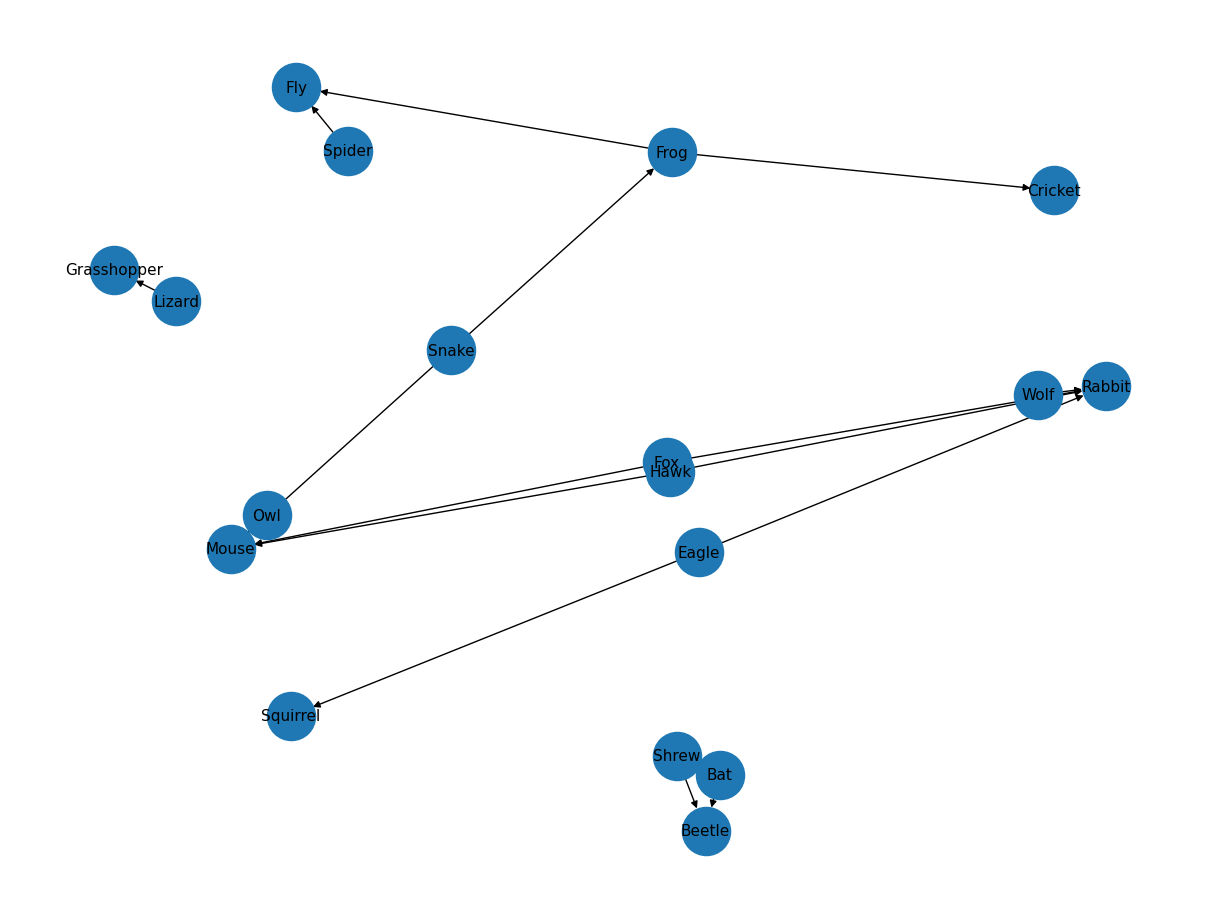

In [145]:
plt.figure(figsize=(12, 9))
display(gold_df)
g = nx.DiGraph()
g.add_edges_from(gold_edges)
pos = nx.spring_layout(g, seed=42)
nx.draw(g, pos, with_labels=True, node_size=1200, font_size=11, arrows=True)
plt.show()

## Utils

In [146]:
#!pip install nltk

In [147]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andiw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andiw\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [148]:
from nltk.corpus import wordnet as wn
from functools import lru_cache

In [149]:
@lru_cache(maxsize=10000)
def get_category(entity):
    """Return a broad biological category for an entity via WordNet."""
    if not entity:
        return None

    normalized = entity.strip().lower()
    try:
        synsets = wn.synsets(normalized, pos=wn.NOUN)
    except LookupError:
        return None
    if not synsets:
        return None

    path = synsets[0].hypernym_paths()[0] if synsets[0].hypernym_paths() else []
    if not path:
        return None

    broad = {"animal", "mammal", "bird", "fish", "insect", "reptile", "amphibian"}
    for h in reversed(path):
        name = h.name().split(".")[0]
        if name in broad:
            return name
    return path[-1].name().split(".")[0]

CATEGORY_ALIASES = {
    "insect": {"insect", "insects", "bug", "bugs"},
    "fish": {"fish", "fishes"},
    "bird": {"bird", "birds"},
    "mammal": {"mammal", "mammals"},
    "reptile": {"reptile", "reptiles"},
    "amphibian": {"amphibian", "amphibians"},
}

MANUAL_CATEGORY_OVERRIDE = {
    "cricket": "insect", "fly": "insect", "beetle": "insect", "grasshopper": "insect", "caterpillar": "insect",
    "frog": "amphibian", "snake": "reptile", "lizard": "reptile",
    "eagle": "bird", "hawk": "bird", "owl": "bird",
}

GENERIC_PREY_BLACKLIST = {"Bird"}
PREDATION_KEYWORDS = {
    "eat", "eats", "ate", "feeding", "feeds", "feed", "hunt", "hunts", "hunted",
    "consume", "consumes", "consumed", "devour", "devours", "devoured", "predate", "predates", "predated",
}
PREDATION_PHRASES = {"feeds on", "preys on", "preyed on", "hunts", "eats", "consumes"}
TAXONOMY_CUES = {"family", "genus", "species", "order", "class", "clade"}


def split_sentences(text):
    return [s for s in re.split(r"(?<=[.!?])\s+", text or "") if s.strip()]


def _entity_regex(entity):
    variants = sorted(get_entity_variants(entity), key=len, reverse=True)
    return r"(?:" + "|".join(re.escape(v) for v in variants) + r")"


def get_alias_to_category_map():
    return {
        alias: category
        for category, aliases in CATEGORY_ALIASES.items()
        for alias in aliases
    }


def build_category_to_animals(all_animals):
    category_to_animals = {}
    for animal in all_animals:
        cat = MANUAL_CATEGORY_OVERRIDE.get(animal.lower()) or get_category(animal)
        if cat:
            category_to_animals.setdefault(cat.lower(), set()).add(animal)
    return category_to_animals


def sentence_has_predation_cue(sentence_lower):
    return any(p in sentence_lower for p in PREDATION_PHRASES) or any(w in sentence_lower for w in PREDATION_KEYWORDS)


def detect_categories_in_sentence(sentence_lower):
    alias_to_category = get_alias_to_category_map()
    return {category for alias, category in alias_to_category.items() if alias in sentence_lower}


def is_taxonomy_statement(sentence_lower):
    return (
        "bird of prey" in sentence_lower
        or "birds of prey" in sentence_lower
        or any(cue in sentence_lower for cue in TAXONOMY_CUES)
    )


def add_non_self_edge(edges, predator, prey):
    if predator.lower() != prey.lower():
        edges.add((predator, prey))


def sanitize_edges(edges, source_set, target_set, all_animals, allowed_targets_by_source=None):
    """Hard constraint: only original-list nodes, valid direction, and optional per-source targets."""
    allowed = set(all_animals)
    cleaned = {
        (s, t)
        for s, t in edges
        if s in allowed and t in allowed and s in source_set and t in target_set and s != t and t not in GENERIC_PREY_BLACKLIST
    }
    if allowed_targets_by_source is None:
        return cleaned
    return {
        (s, t)
        for s, t in cleaned
        if s in allowed_targets_by_source and t in allowed_targets_by_source[s]
    }


def expand_category_mentions(
    sentence_lower,
    predator,
    all_animals,
    category_to_animals,
    allowed_categories=None,
    source_allowlist=None,
):
    """Expand category mentions to concrete prey nodes with optional filters."""
    if source_allowlist is not None and predator not in source_allowlist:
        return set()

    detected = detect_categories_in_sentence(sentence_lower)
    if allowed_categories is not None:
        allowed_categories = set(allowed_categories)
        detected = {c for c in detected if c in allowed_categories}

    expanded = set()
    for category in detected:
        for prey in category_to_animals.get(category, set()):
            if prey in all_animals and prey.lower() != predator.lower():
                expanded.add(prey)
    return expanded


def balanced_category_expansion(
    sentence_lower,
    predator,
    all_animals_set,
    category_to_animals,
    allowed_categories=None,
    source_allowlist=None,
):
    """Generic balanced category expansion helper used by methods A/B/C."""
    return expand_category_mentions(
        sentence_lower,
        predator,
        all_animals_set,
        category_to_animals,
        allowed_categories=allowed_categories,
        source_allowlist=source_allowlist,
    )


print("Category utilities ready.")

Category utilities ready.


In [150]:
def get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY):
    """Return global source and target constraints for predator->prey extraction."""
    source_set = set(PREDATORS + MID_LEVEL)
    target_set = set(MID_LEVEL + PREY)
    return source_set, target_set

def get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY):
    """Precision-oriented constraints per source node.

    - Top predators can target MID_LEVEL and PREY
    - Mid-level predators can target PREY only
    """
    allowed = {}
    for src in PREDATORS:
        allowed[src] = set(MID_LEVEL + PREY)
    for src in MID_LEVEL:
        allowed[src] = set(PREY)
    return allowed

In [151]:
IRREGULAR_ENTITY_VARIANTS = {
    "mouse": {"mouse", "mice"},
    "fly": {"fly", "flies"},
    "wolf": {"wolf", "wolves"},
    "fox": {"fox", "foxes"},
    "bird": {"bird", "birds"},
}

def get_entity_variants(entity):
    e = entity.lower()
    variants = set(IRREGULAR_ENTITY_VARIANTS.get(e, {e}))
    if e not in IRREGULAR_ENTITY_VARIANTS:
        if e.endswith("y") and len(e) > 1 and e[-2] not in "aeiou":
            variants.add(e[:-1] + "ies")
        elif e.endswith(("s", "x", "z", "ch", "sh")):
            variants.add(e + "es")
        else:
            variants.add(e + "s")
    return variants

def mentions_entity(sentence_lower, entity):
    return any(
        re.search(rf"\b{re.escape(variant)}\b", sentence_lower)
        for variant in get_entity_variants(entity)
    )

def extract_edges_from_text(source, text, target_set, all_animals_set, category_to_animals, use_category_expansion=True):
    """Shared sentence extractor used by Methods A and C."""
    edges = set()
    for sent in re.split(r"(?<=[.!?])\s+", text):
        s_lower = sent.lower()
        if not mentions_entity(s_lower, source):
            continue
        if is_taxonomy_statement(s_lower):
            continue
        if not sentence_has_predation_cue(s_lower):
            continue

        for prey in target_set:
            if mentions_entity(s_lower, prey):
                add_non_self_edge(edges, source, prey)

        if use_category_expansion:
            expanded = expand_category_mentions(
                s_lower, source, all_animals_set, category_to_animals
            )
            for prey in expanded:
                if prey in target_set:
                    add_non_self_edge(edges, source, prey)
    return edges

---
## Section 3 – Method A: Co-occurrence

Create an edge A→B when both animals appear in the same sentence.

**Expected:** high recall, lower precision.


In [152]:
import time
import networkx as nx

def co_occurrence_graph(use_category_expansion=True):
    """Method A: sentence co-occurrence baseline with balanced precision/recall tuning."""
    t0 = time.time()
    source_set, target_set = get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY)
    allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
    all_animals_set = set(ALL_ANIMALS)
    category_to_animals = build_category_to_animals(ALL_ANIMALS)
    mid_level_set = set(MID_LEVEL)
    # Example profile: balanced expansion limited to insect class for mid-level sources.
    balanced_categories = {"insect"}

    edges_A = set()
    for predator in source_set:
        text = wiki_corpus.get(predator, {}).get("text", "")
        edges_A |= extract_edges_from_text(
            predator,
            text,
            target_set,
            all_animals_set,
            category_to_animals,
            use_category_expansion=False,
        )

        if not use_category_expansion:
            continue

        for s in map(str.lower, split_sentences(text)):
            if not mentions_entity(s, predator) or not sentence_has_predation_cue(s):
                continue
            for prey in balanced_category_expansion(
                s,
                predator,
                all_animals_set,
                category_to_animals,
                allowed_categories=balanced_categories,
                source_allowlist=mid_level_set,
            ):
                if prey in target_set and prey in allowed_targets_by_source.get(predator, set()):
                    add_non_self_edge(edges_A, predator, prey)

    edges_A = sanitize_edges(edges_A, source_set, target_set, ALL_ANIMALS, allowed_targets_by_source)
    graph_A = nx.DiGraph()
    graph_A.add_edges_from(edges_A)
    return graph_A, edges_A, time.time() - t0

graph_A, edges_A, time_A = co_occurrence_graph(use_category_expansion=True)
len(edges_A)

31

### 3.2 Method A – Results

Inspect the extracted edges and visualise the resulting graph.

Edges 31
[('Snake', 'Lizard'), ('Frog', 'Fly'), ('Snake', 'Mouse'), ('Frog', 'Beetle'), ('Shrew', 'Fly'), ('Shrew', 'Beetle'), ('Spider', 'Fly'), ('Hawk', 'Rabbit'), ('Spider', 'Beetle'), ('Frog', 'Mouse'), ('Lizard', 'Fly'), ('Lizard', 'Beetle'), ('Bat', 'Fly'), ('Bat', 'Beetle'), ('Frog', 'Cricket'), ('Frog', 'Grasshopper'), ('Shrew', 'Cricket'), ('Shrew', 'Grasshopper'), ('Snake', 'Frog'), ('Hawk', 'Squirrel')]


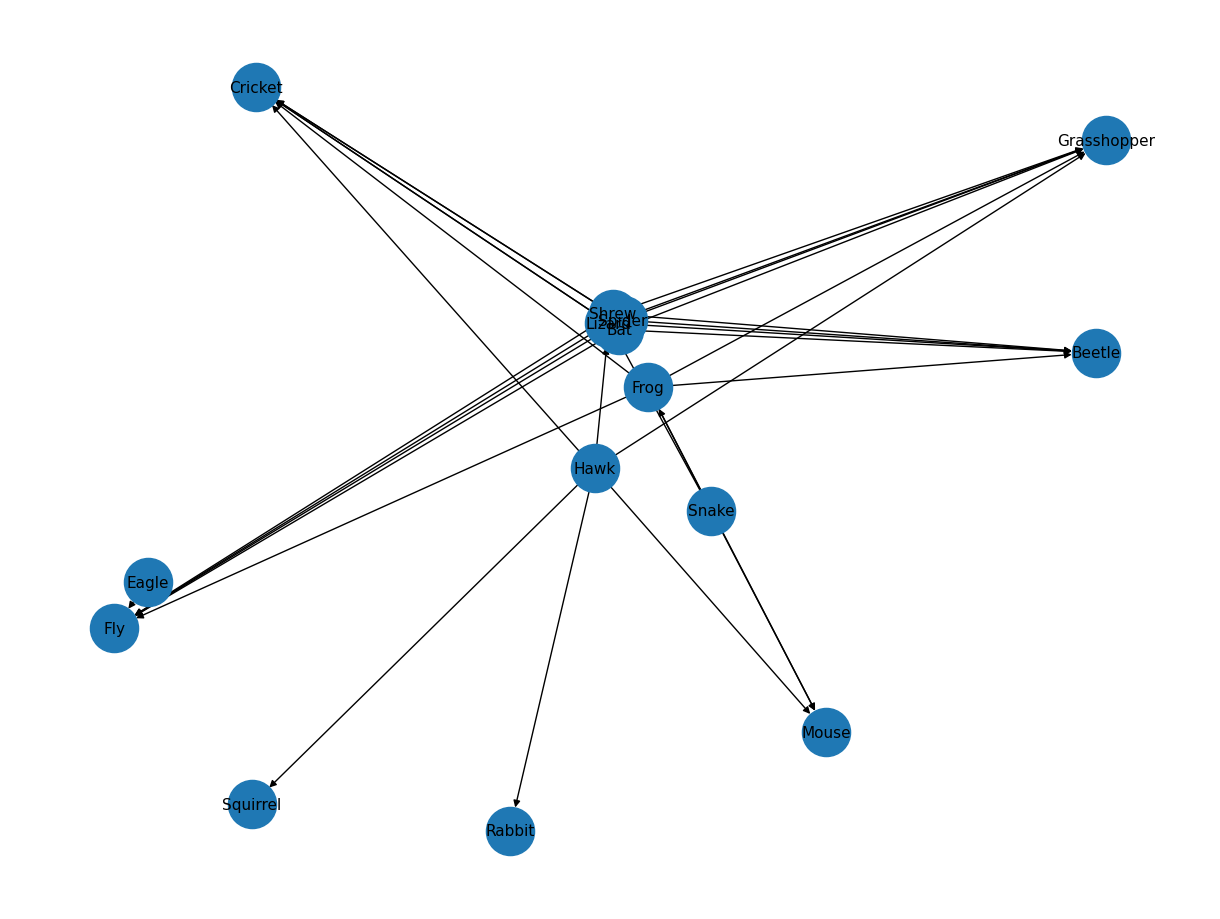

In [153]:
plt.figure(figsize=(12, 9))
print("Edges", len(edges_A))
print(list(edges_A)[:20])
nx.draw(
    graph_A,
    nx.spring_layout(graph_A, seed=1),
    with_labels=True,
    node_size=1200,
    font_size=11,
    arrows=True,
)
plt.show()

---
## Section 4 – Method B: Dependency Patterns

Use dependency parsing and hand-crafted patterns such as *eats*, *hunts*, *preys on* and *feeds on* to extract explicit predator→prey relations.

**Expected:** highest precision.


In [154]:
#!python -m spacy download en_core_web_sm

In [155]:
import time
import spacy
import networkx as nx
from spacy.matcher import PhraseMatcher

try:
    nlp = spacy.load("en_core_web_sm")
    HAS_DEP_PARSER = True
except OSError:
    nlp = spacy.blank("en")
    if "sentencizer" not in nlp.pipe_names:
        nlp.add_pipe("sentencizer")
    HAS_DEP_PARSER = False
    print("spaCy model 'en_core_web_sm' not available. Method B will run in lexical fallback mode.")


def build_predation_graph_method_b(wiki_corpus, PREDATORS, MID_LEVEL, ALL_ANIMALS, max_text_len=200000):
    """Method B: dependency patterns + balanced fallback tuning."""
    t0 = time.time()
    edges, evidence = set(), []

    predators = PREDATORS + MID_LEVEL
    source_set, target_set = get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY)
    allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
    animals_set = {a.lower() for a in ALL_ANIMALS}
    all_animals_set = set(ALL_ANIMALS)
    category_to_animals = build_category_to_animals(ALL_ANIMALS)
    mid_level_set = set(MID_LEVEL)
    # Example profile: balanced expansion limited to insect class for mid-level sources.
    balanced_categories = {"insect"}

    matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
    matcher.add("ANIMALS", [nlp.make_doc(a) for a in ALL_ANIMALS])
    predation_lemmas = {"prey", "feed", "hunt", "eat", "attack", "kill", "consume", "devour", "predate"}
    rel = r"(?:feeds?\s+on|preys?\s+on|hunts?|eats?|consumes?|devours?|predates?\s+on)"

    def add_edge(predator_name, prey_name, sentence_text):
        if predator_name not in source_set or prey_name not in target_set:
            return
        if prey_name not in allowed_targets_by_source.get(predator_name, set()):
            return
        if is_taxonomy_statement(sentence_text.lower()):
            return
        before = len(edges)
        add_non_self_edge(edges, predator_name, prey_name)
        if len(edges) > before:
            evidence.append((predator_name, prey_name, sentence_text))

    def strict_lexical_match(source, prey, sentence_lower):
        src, tgt = _entity_regex(source), _entity_regex(prey)
        pat = rf"\b{src}\b[\s\S]{{0,120}}{rel}[\s\S]{{0,120}}\b{tgt}\b"
        return re.search(pat, sentence_lower) is not None

    def add_balanced_expansion(predator, sentence_lower, sentence_text):
        for prey in balanced_category_expansion(
            sentence_lower,
            predator,
            all_animals_set,
            category_to_animals,
            allowed_categories=balanced_categories,
            source_allowlist=mid_level_set,
        ):
            if prey in target_set and prey in allowed_targets_by_source.get(predator, set()):
                add_edge(predator, prey, sentence_text)

    for predator in predators:
        if predator not in source_set:
            continue

        text = wiki_corpus.get(predator, {}).get("text", "")[:max_text_len]
        doc = nlp(text)

        for sent in doc.sents:
            sent_text = sent.text if hasattr(sent, "text") else str(sent)
            sent_lower = sent_text.lower()
            if is_taxonomy_statement(sent_lower):
                continue
            if not any(a in sent_lower for a in animals_set) and not detect_categories_in_sentence(sent_lower):
                continue

            if not HAS_DEP_PARSER:
                if mentions_entity(sent_lower, predator) and sentence_has_predation_cue(sent_lower):
                    for prey in target_set:
                        if prey in allowed_targets_by_source.get(predator, set()) and strict_lexical_match(predator, prey, sent_lower):
                            add_edge(predator, prey, sent_text)
                    add_balanced_expansion(predator, sent_lower, sent_text)
                continue

            sent_doc = nlp(sent_text)
            spans = {sent_doc[start:end].text.lower(): sent_doc[start:end].text for _, start, end in matcher(sent_doc)}

            for token in sent_doc:
                if token.pos_ != "VERB" or token.lemma_.lower() not in predation_lemmas:
                    continue

                subjects = [w for w in token.lefts if w.dep_ in ("nsubj", "nsubjpass")]
                if not any(s.lemma_.lower() == predator.lower() or s.text.lower() == predator.lower() for s in subjects):
                    continue

                objects = [w for w in token.rights if w.dep_ in ("dobj", "obj", "attr", "oprd")]
                for obj in objects:
                    key = obj.text.lower()
                    candidate = spans.get(key)
                    if candidate in target_set:
                        add_edge(predator, candidate, sent_text)

                for child in token.children:
                    if child.dep_ == "prep" and child.text.lower() == "on":
                        for obj in child.children:
                            key = obj.text.lower()
                            candidate = spans.get(key)
                            if candidate in target_set:
                                add_edge(predator, candidate, sent_text)

                if sentence_has_predation_cue(sent_lower):
                    add_balanced_expansion(predator, sent_lower, sent_text)

    edges = sanitize_edges(edges, source_set, target_set, ALL_ANIMALS, allowed_targets_by_source)
    graph = nx.DiGraph()
    graph.add_edges_from(edges)
    return graph, edges, evidence, time.time() - t0

### 4.3 Method B – Results

Inspect extracted edges, highlight any interesting dependency parses, and visualise the graph.

In [156]:
graph_B, edges_B, evidence_B, time_B = build_predation_graph_method_b(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    ALL_ANIMALS,
    max_text_len=200000,
)

print("Edges:", len(edges_B))
print("Time (s):", time_B)
print("Evidence sample:", evidence_B[:5])

Edges: 4
Time (s): 31.50646948814392
Evidence sample: [('Bat', 'Fly', 'Bats consume insect pests, reducing the need for pesticides and other insect management measures.'), ('Bat', 'Beetle', 'Bats consume insect pests, reducing the need for pesticides and other insect management measures.'), ('Bat', 'Grasshopper', 'Bats consume insect pests, reducing the need for pesticides and other insect management measures.'), ('Bat', 'Cricket', 'Bats consume insect pests, reducing the need for pesticides and other insect management measures.')]


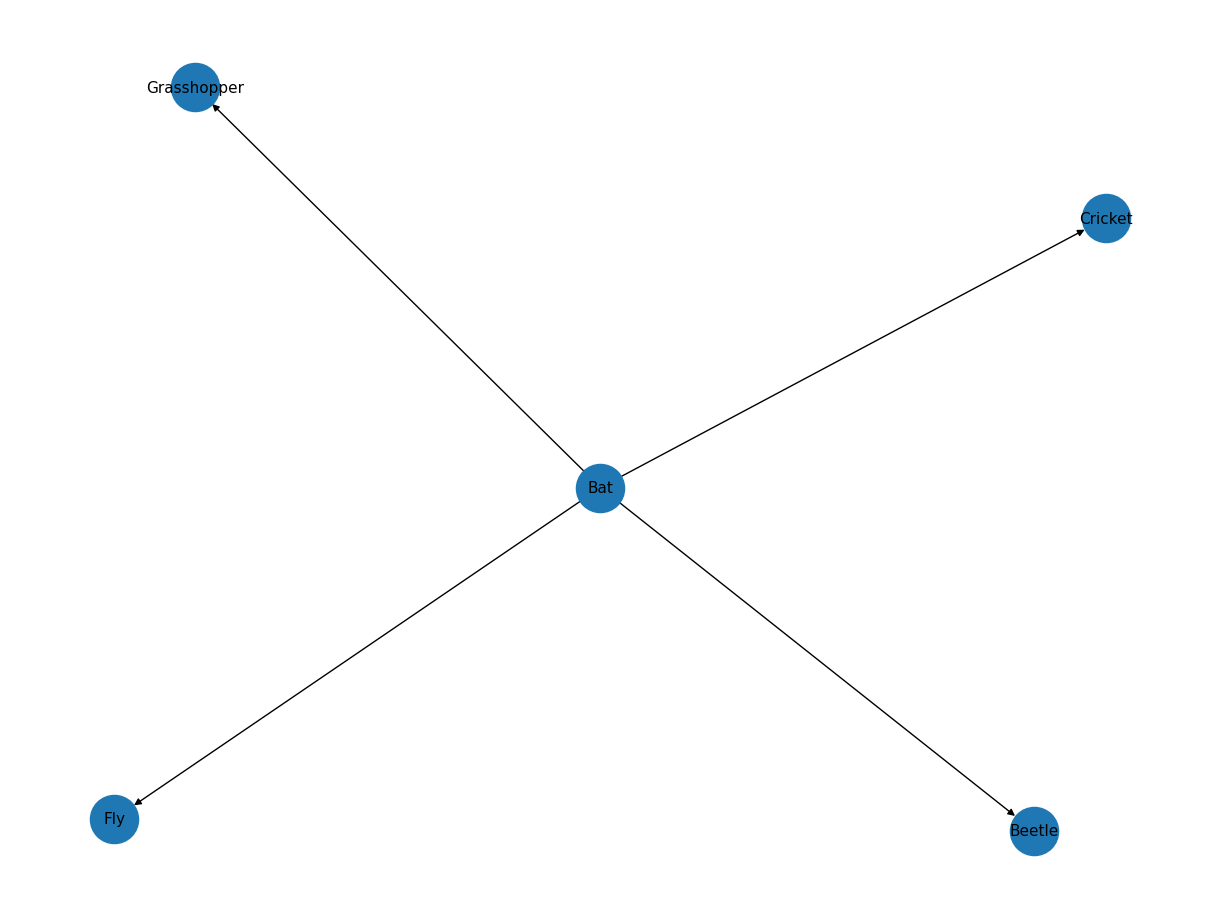

In [157]:

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(graph_B, seed=2)
nx.draw(
    graph_B,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=11,
    arrows=True,
)
plt.show()

---
## Section 5 – Method C: OpenIE-style Relation Extraction

Extract subject–relation–object triples from sentences and keep relations that express predation.

Example:

`Fox feeds on rabbits` → `(Fox, feeds on, Rabbit)`

Target relations include:
- eats
- feeds on
- hunts
- preys on
- consumes

**Expected:** better recall than dependency rules while remaining relation-focused.


In [158]:
t0 = time.time()
source_set, target_set = get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY)
allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
all_animals_set = set(ALL_ANIMALS)
category_to_animals = build_category_to_animals(ALL_ANIMALS)
mid_level_set = set(MID_LEVEL)
# Example profile: balanced expansion limited to insect class for mid-level sources.
balanced_categories = {"insect"}


def _phrase_to_regex(phrase):
    return re.escape(phrase.strip().lower()).replace(r"\ ", r"\s+")


def _normalize_verb_form(token):
    token = token.strip().lower()
    irregular = {
        "ate": "eat", "eaten": "eat",
        "fed": "feed", "feeds": "feed", "feeding": "feed",
        "preys": "prey", "preyed": "prey", "preying": "prey",
    }
    if token in irregular:
        return irregular[token]
    if token.endswith("ies") and len(token) > 3:
        return token[:-3] + "y"
    if token.endswith("ing") and len(token) > 4:
        return token[:-3]
    if token.endswith("ed") and len(token) > 3:
        return token[:-2]
    if token.endswith("es") and len(token) > 3:
        return token[:-2]
    if token.endswith("s") and len(token) > 3:
        return token[:-1]
    return token


def _past_participle(verb):
    irregular_pp = {"eat": "eaten", "feed": "fed"}
    if verb in irregular_pp:
        return irregular_pp[verb]
    if verb.endswith("e"):
        return verb + "d"
    return verb + "ed"


def _build_openie_patterns_from_cues():
    relation_cues = {cue.lower() for cue in (set(PREDATION_PHRASES) | set(PREDATION_KEYWORDS)) if cue.strip()}
    relation_patterns = sorted({_phrase_to_regex(cue) for cue in relation_cues}, key=len, reverse=True)

    relation_roots = {_normalize_verb_form(cue.split()[0]) for cue in relation_cues if cue.split()}
    passive_patterns = set()
    for verb in relation_roots:
        pp = _past_participle(verb)
        passive_cores = {pp}
        if verb == "prey":
            passive_cores |= {r"preyed\s+upon", r"preyed\s+on"}
        if verb in {"feed", "predate"}:
            passive_cores.add(pp + r"\s+on")
        for core in passive_cores:
            passive_patterns.add(rf"(?:is|are|was|were)\s+{core}\s+by")

    return relation_patterns, sorted(passive_patterns, key=len, reverse=True)


OPENIE_RELATION_PATTERNS, OPENIE_PASSIVE_PATTERNS = _build_openie_patterns_from_cues()
REL_REGEX = re.compile(r"(?:" + "|".join(OPENIE_RELATION_PATTERNS) + r")")
IMPLICIT_REL_REGEX = REL_REGEX
PASSIVE_REGEX = re.compile(r"(?:" + "|".join(OPENIE_PASSIVE_PATTERNS) + r")")


def has_reverse_blocker(source, prey, sentence_lower):
    src, tgt = _entity_regex(source), _entity_regex(prey)
    blk = PASSIVE_REGEX.pattern
    return re.search(rf"\b{src}\b[\s\S]{{0,80}}(?:{blk})[\s\S]{{0,80}}\b{tgt}\b", sentence_lower) is not None


def _first_clause_after(text, idx, max_len=220):
    segment = text[idx:idx + max_len]
    split = re.split(r"[.;:!?]", segment, maxsplit=1)
    return split[0] if split else segment


def _mentions_other_source(sentence_lower, source):
    for candidate in source_set:
        if candidate == source:
            continue
        if mentions_entity(sentence_lower, candidate):
            return True
    return False


def openie_relation_match(source, prey, sentence_lower):
    if not mentions_entity(sentence_lower, prey):
        return False
    if is_taxonomy_statement(sentence_lower):
        return False

    src, tgt = _entity_regex(source), _entity_regex(prey)

    # Explicit source-based matching (main path).
    if mentions_entity(sentence_lower, source):
        if has_reverse_blocker(source, prey, sentence_lower):
            return False

        active_direct = re.search(rf"\b{src}\b[\s\S]{{0,180}}(?:{REL_REGEX.pattern})[\s\S]{{0,220}}\b{tgt}\b", sentence_lower)
        if active_direct:
            return True

        src_hits = [m.start() for m in re.finditer(rf"\b{src}\b", sentence_lower)]
        for rel_match in REL_REGEX.finditer(sentence_lower):
            rel_pos = rel_match.start()
            if min(abs(rel_pos - s_pos) for s_pos in src_hits) > 220:
                continue
            relation_scope = _first_clause_after(sentence_lower, rel_match.end(), max_len=260)
            if mentions_entity(relation_scope, prey):
                return True

        passive = re.search(rf"\b{tgt}\b[\s\S]{{0,180}}(?:{PASSIVE_REGEX.pattern})[\s\S]{{0,140}}\b{src}\b", sentence_lower)
        return passive is not None

    # Implicit page-subject main-path matching, tightened for precision.
    if _mentions_other_source(sentence_lower, source):
        return False
    if PASSIVE_REGEX.search(sentence_lower):
        return False

    for rel_match in IMPLICIT_REL_REGEX.finditer(sentence_lower):
        relation_scope = _first_clause_after(sentence_lower, rel_match.end(), max_len=200)
        if mentions_entity(relation_scope, prey):
            # Additional precision guard: avoid generic catch-all list tails.
            if any(noisy in relation_scope for noisy in ["small game", "other type", "variety of"]):
                continue
            return True

    return False


def has_strong_category_cue(sentence_lower):
    return sentence_has_predation_cue(sentence_lower)


edges_C = set()
for source in source_set:
    text = wiki_corpus.get(source, {}).get("text", "")
    for s in map(str.lower, split_sentences(text)):
        explicit_added = False

        for prey in target_set:
            if source == prey or prey not in allowed_targets_by_source.get(source, set()):
                continue
            if openie_relation_match(source, prey, s):
                add_non_self_edge(edges_C, source, prey)
                explicit_added = True

        # Category expansion remains gated and secondary to explicit OpenIE matches.
        if not explicit_added and mentions_entity(s, source) and has_strong_category_cue(s):
            for prey in balanced_category_expansion(
                s,
                source,
                all_animals_set,
                category_to_animals,
                allowed_categories=balanced_categories,
                source_allowlist=mid_level_set,
            ):
                if prey in target_set and prey in allowed_targets_by_source.get(source, set()) and not has_reverse_blocker(source, prey, s):
                    add_non_self_edge(edges_C, source, prey)

edges_C = sanitize_edges(edges_C, source_set, target_set, ALL_ANIMALS, allowed_targets_by_source)
time_C = time.time() - t0
graph_C = nx.DiGraph()
graph_C.add_edges_from(edges_C)

### 5.2 Method C – Results

Inspect extracted triples and compare them with the dependency-based approach.


Edges 31
[('Snake', 'Lizard'), ('Frog', 'Fly'), ('Snake', 'Mouse'), ('Frog', 'Beetle'), ('Shrew', 'Fly'), ('Shrew', 'Beetle'), ('Spider', 'Fly'), ('Hawk', 'Rabbit'), ('Spider', 'Beetle'), ('Frog', 'Mouse'), ('Lizard', 'Fly'), ('Lizard', 'Beetle'), ('Bat', 'Fly'), ('Bat', 'Beetle'), ('Frog', 'Cricket'), ('Frog', 'Grasshopper'), ('Shrew', 'Cricket'), ('Shrew', 'Grasshopper'), ('Snake', 'Frog'), ('Hawk', 'Squirrel')]


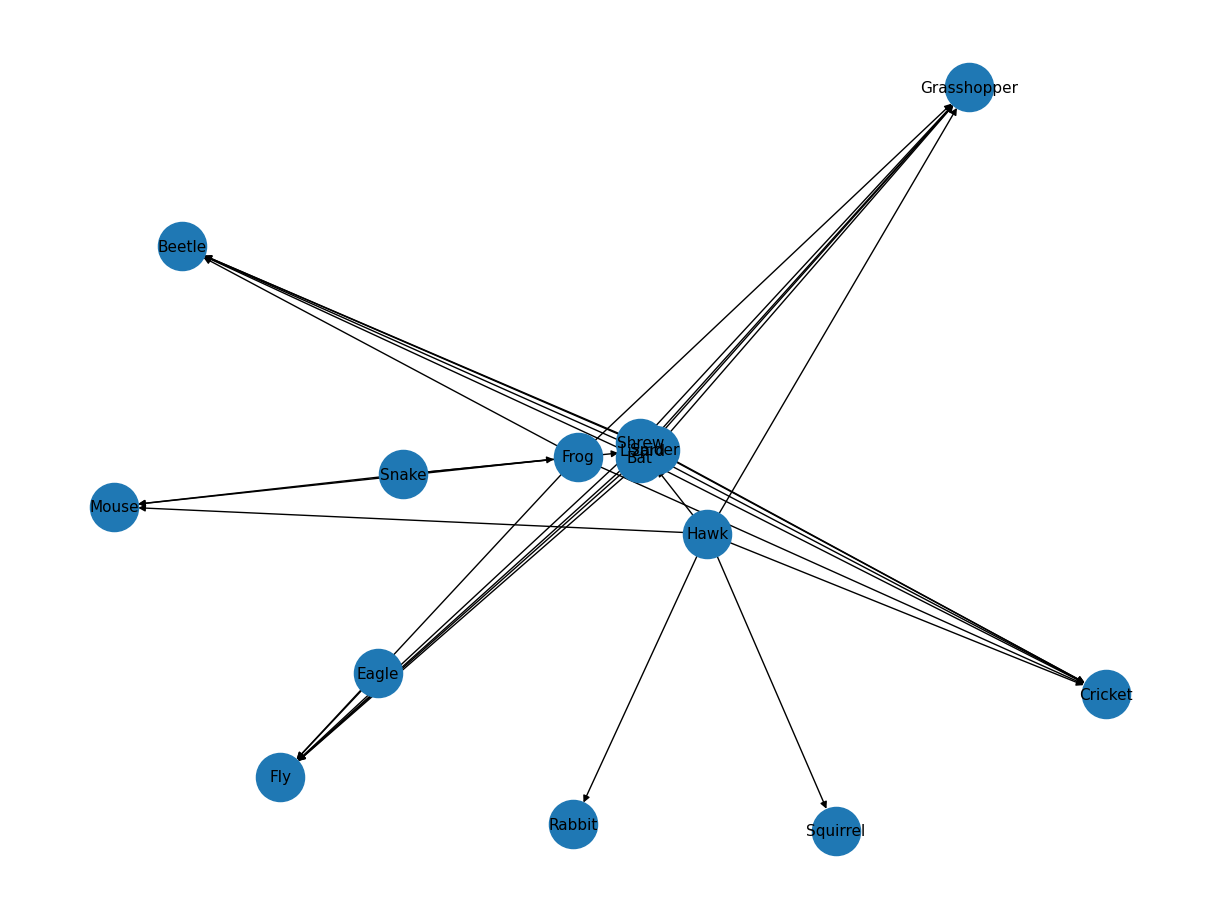

In [159]:
plt.figure(figsize=(12, 9))
print("Edges", len(edges_C))
print(list(edges_C)[:20])
nx.draw(
    graph_C,
    nx.spring_layout(graph_C, seed=3),
    with_labels=True,
    node_size=1200,
    font_size=11,
    arrows=True,
)
plt.show()

---
## Section 6 – Evaluation & Comparison

All three methods are evaluated against the gold standard using the same evaluation function. Only edges where the **source is in PREDATORS ∪ MID_LEVEL** and the **target is in MID_LEVEL ∪ PREY** are considered.

### 6.1 Evaluation Function

$$\text{Precision} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{predicted}|}$$

$$\text{Recall} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{gold}|}$$

$$\text{F1} = \frac{2 \cdot P \cdot R}{P + R}$$

In [160]:
def evaluate(predicted_edges,gold_edges,label=''):
 tp=len(predicted_edges & gold_edges)
 fp=len(predicted_edges-gold_edges)
 fn=len(gold_edges-predicted_edges)
 p=tp/(tp+fp) if tp+fp else 0
 r=tp/(tp+fn) if tp+fn else 0
 f=2*p*r/(p+r) if p+r else 0
 return {'method':label,'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn}


### 6.2 Run Evaluation for All Methods

In [161]:
eval_A = evaluate(edges_A, gold_edges, "A")
eval_B = evaluate(edges_B, gold_edges, "B")
eval_C = evaluate(edges_C, gold_edges, "C")

results = pd.DataFrame([eval_A, eval_B, eval_C])
results = results[["method", "precision", "recall", "f1", "tp", "fp", "fn"]]
results[["precision", "recall", "f1"]] = results[["precision", "recall", "f1"]].round(3)

styled_results = (
    results.style
    .set_caption("Method Comparison: Edge-level Evaluation")
    .background_gradient(subset=["precision", "recall", "f1"], cmap="YlGn")
    .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"})
)
display(styled_results)

,method,precision,recall,f1,tp,fp,fn
0,A,0.323,0.625,0.426,10,21,6
1,B,0.250,0.062,0.100,1,3,15
2,C,0.323,0.625,0.426,10,21,6


In [162]:
results_plain = pd.DataFrame([
    evaluate(edges_A, gold_edges, "A"),
    evaluate(edges_B, gold_edges, "B"),
    evaluate(edges_C, gold_edges, "C"),
])[["method", "precision", "recall", "f1", "tp", "fp", "fn"]]
print(results_plain.round(3).to_string(index=False))

method  precision  recall    f1  tp  fp  fn
     A      0.323   0.625 0.426  10  21   6
     B      0.250   0.062 0.100   1   3  15
     C      0.323   0.625 0.426  10  21   6


### 6.3 Graph Structure Statistics

For each method's graph we report:
- Number of nodes and edges
- Graph density
- Average in-degree and out-degree
- Longest predation chain (longest directed path)

In [163]:
def graph_stats(g,name):
 return {'graph':name,'nodes':g.number_of_nodes(),'edges':g.number_of_edges(),'density':nx.density(g) if g.number_of_nodes()>1 else 0}
pd.DataFrame([graph_stats(graph_A,'A'),graph_stats(graph_B,'B'),graph_stats(graph_C,'C')])


,graph,nodes,edges,density
0,A,15,31,0.147619
1,B,5,4,0.200000
2,C,15,31,0.147619


### 6.4 Comparison Plots

We produce the following visualisations:

1. **Grouped bar chart** – Precision / Recall / F1 per method
2. **Runtime bar chart** – seconds per method
3. **Edge Venn / upset plot** – overlap of predicted edges between methods
4. **Graph visualisations** – side-by-side NetworkX plots of the three graphs, coloured by trophic level

<Axes: xlabel='method'>

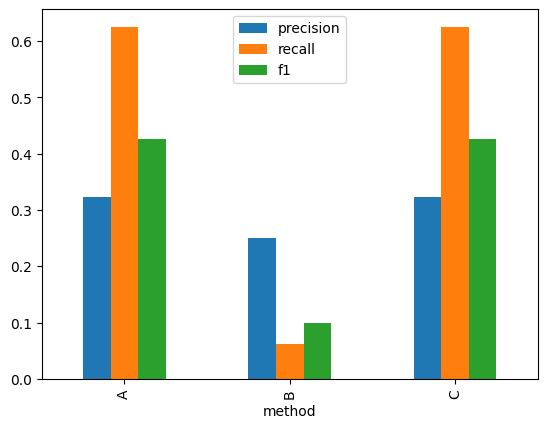

In [164]:
results.set_index('method')[['precision','recall','f1']].plot(kind='bar')


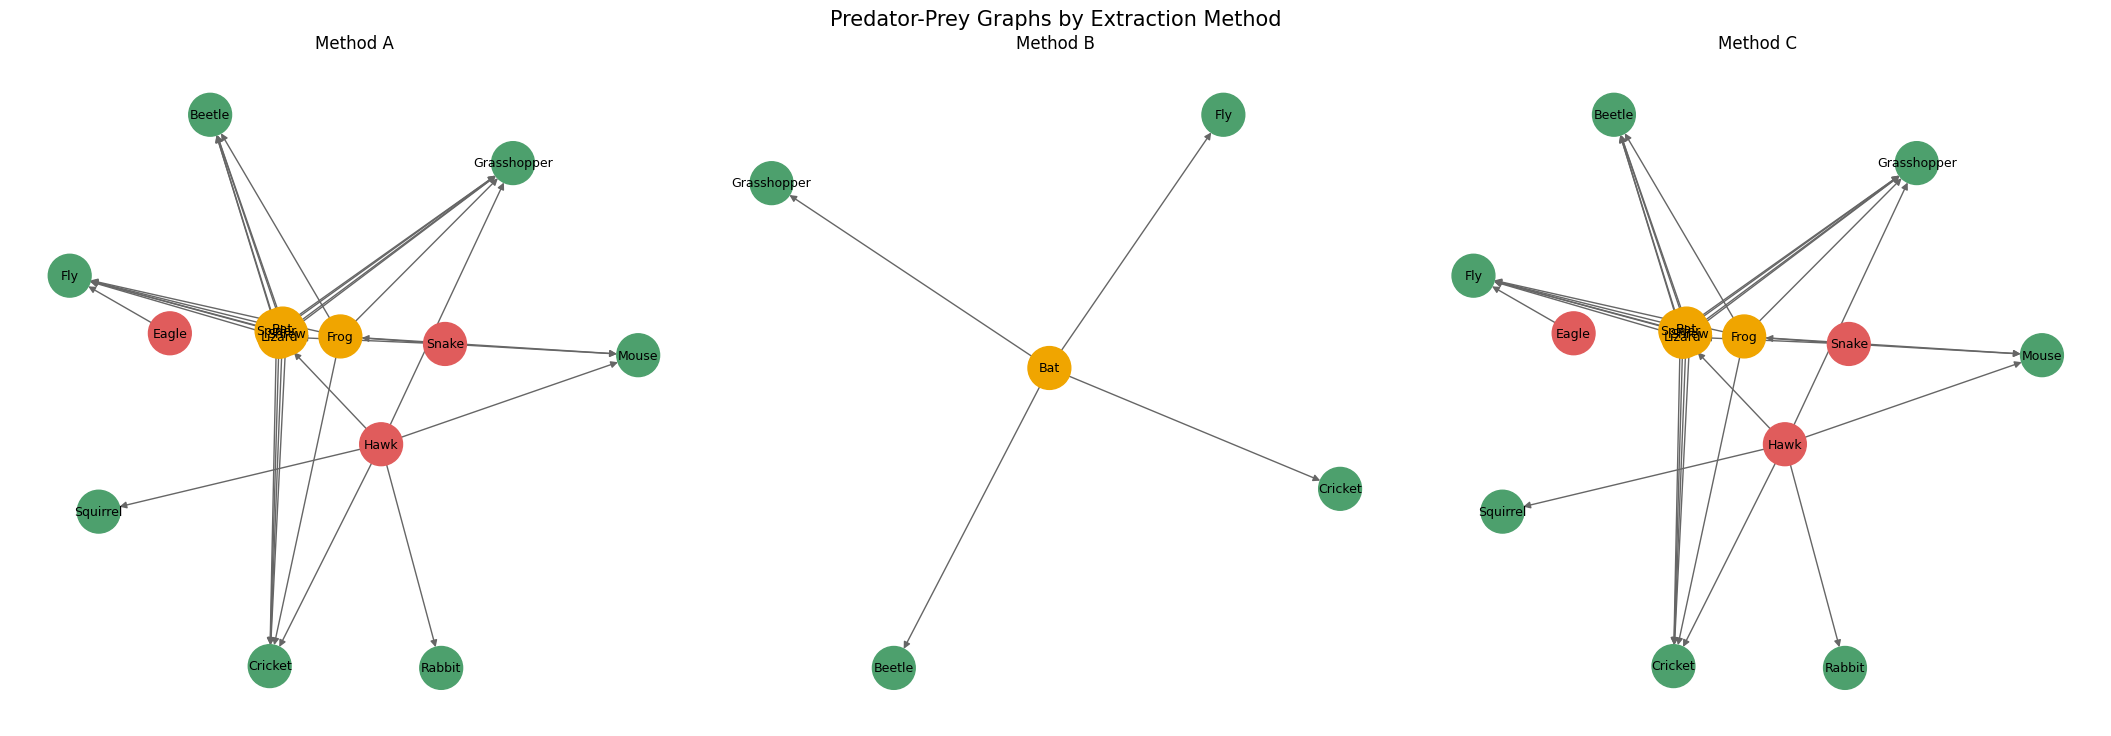

In [165]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=True)
for ax, g, t in zip(axs, [graph_A, graph_B, graph_C], ["Method A", "Method B", "Method C"]):
    node_colors = [TROPHIC_COLOR.get(node, "#8da0cb") for node in g.nodes()]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(
        g,
        ax=ax,
        pos=pos,
        with_labels=True,
        node_size=950,
        font_size=9,
        arrows=True,
        edge_color="#666666",
        node_color=node_colors,
    )
    ax.set_title(t, fontsize=12)

plt.suptitle("Predator-Prey Graphs by Extraction Method", fontsize=15, y=1.03)
plt.show()

### 6.5 Error Analysis

For each method, we inspect:
- **False positives** (edges predicted but not in gold) — what kinds of co-occurrences / links / parses cause them?
- **False negatives** (gold edges missed) — what linguistic patterns were not captured?

In [166]:
for name,edges in [('A',edges_A),('B',edges_B),('C',edges_C)]:
 print(name,'FP',list(edges-gold_edges)[:10])
 print(name,'FN',list(gold_edges-edges)[:10])


A FP [('Snake', 'Lizard'), ('Frog', 'Beetle'), ('Shrew', 'Fly'), ('Spider', 'Beetle'), ('Frog', 'Mouse'), ('Lizard', 'Fly'), ('Lizard', 'Beetle'), ('Bat', 'Fly'), ('Frog', 'Grasshopper'), ('Shrew', 'Cricket')]
A FN [('Wolf', 'Rabbit'), ('Eagle', 'Rabbit'), ('Owl', 'Mouse'), ('Fox', 'Mouse'), ('Eagle', 'Squirrel'), ('Fox', 'Rabbit')]
B FP [('Bat', 'Cricket'), ('Bat', 'Grasshopper'), ('Bat', 'Fly')]
B FN [('Spider', 'Fly'), ('Hawk', 'Rabbit'), ('Lizard', 'Grasshopper'), ('Frog', 'Fly'), ('Snake', 'Mouse'), ('Wolf', 'Rabbit'), ('Snake', 'Frog'), ('Eagle', 'Rabbit'), ('Owl', 'Mouse'), ('Shrew', 'Beetle')]
C FP [('Snake', 'Lizard'), ('Frog', 'Beetle'), ('Shrew', 'Fly'), ('Spider', 'Beetle'), ('Frog', 'Mouse'), ('Lizard', 'Fly'), ('Lizard', 'Beetle'), ('Bat', 'Fly'), ('Frog', 'Grasshopper'), ('Shrew', 'Cricket')]
C FN [('Wolf', 'Rabbit'), ('Eagle', 'Rabbit'), ('Owl', 'Mouse'), ('Fox', 'Mouse'), ('Eagle', 'Squirrel'), ('Fox', 'Rabbit')]



## Section 7 – Discussion

